# Clasificación del Consumo de Psicofármacos con Machine Learning

## Objetivo

### El objetivo de este trabajo es aplicar modelos de aprendizaje automático supervisado para clasificar el consumo de psicofármacos en Argentina, comparando el desempeño de dos algoritmos:

### - K-Nearest Neighbors (KNN)
### - Árbol de Decisión

### Se analizarán métricas de evaluación y matrices de confusión para determinar cuál modelo obtiene mejores resultados.


## Dataset utilizado

## Dataset: psicofarmacos_argentina.csv

### El dataset contiene información relacionada con:

### - Ansiolíticos
### - Antidepresivos
### - Antipsicóticos
### - Hipnóticos
### - Consumo total

### Cantidad de registros:
### - 18 filas

### Cantidad de variables:
### - 7 columnas


### Variable objetivo

### La variable original `total_consumo` fue transformada en una clasificación binaria:

### - Consumo bajo → clase 0
### - Consumo alto → clase 1

Esto permite trabajar con algoritmos de clasificación supervisada.


### IMPORTACION DE LIBRERIAS 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score
)

### CARGA DEL SET DE DATOS 

In [2]:
df = pd.read_csv("psicofarmacos_argentina.csv")

df.head()

,anio,mes,ansioliticos,antidepresivos,antipsicoticos,hipnoticos,total_consumo
0,2023,1,120,95,40,60,315
1,2023,2,125,98,42,62,327
2,2023,3,130,102,43,65,340
3,2023,4,128,100,45,63,336
4,2023,5,135,105,46,68,354


### CREACION DE LA VARIABLE BINARIA 

In [5]:
df.columns

Index(['anio', 'mes', 'ansioliticos', 'antidepresivos', 'antipsicoticos',
       'hipnoticos', 'total_consumo', 'consumo_alto'],
      dtype='object')

In [6]:
df.columns = df.columns.str.strip()

df.columns

Index(['anio', 'mes', 'ansioliticos', 'antidepresivos', 'antipsicoticos',
       'hipnoticos', 'total_consumo', 'consumo_alto'],
      dtype='object')

In [7]:
mediana = df["total_consumo"].median()

df["consumo_alto"] = np.where(
    df["total_consumo"] >= mediana,
    1,
    0
)

df[[
    "total_consumo",
    "consumo_alto"
]]

,total_consumo,consumo_alto
0,315,0
1,327,0
2,340,0
3,336,0
4,354,0
5,368,0
6,382,0
7,397,0
8,391,0
9,411,1


### MOTRAR TABLA 

In [10]:
df[[
    "total_consumo",
    "consumo_alto"
]].head()

,total_consumo,consumo_alto
0,315,0
1,327,0
2,340,0
3,336,0
4,354,0


### DISTRIBUCION DE CLASES 

In [13]:
df["consumo_alto"].value_counts().to_frame()

,count
consumo_alto,
0,9
1,9


### Selección de variables

### Variables predictoras:

### * ansioliticos
### * antidepresivos
### * antipsicoticos
### * hipnoticos

### Variable objetivo:

### consumo_alto

In [14]:
X = df[[
    "ansioliticos",
    "antidepresivos",
    "antipsicoticos",
    "hipnoticos"
]]

y = df["consumo_alto"]

X.head()

,ansioliticos,antidepresivos,antipsicoticos,hipnoticos
0,120,95,40,60
1,125,98,42,62
2,130,102,43,65
3,128,100,45,63
4,135,105,46,68


### División de entrenamiento y prueba

### Se utilizó una división:

### 80% entrenamiento
### 20% prueb

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

pd.DataFrame({
    "Conjunto": ["Entrenamiento", "Prueba"],
    "Cantidad": [len(X_train), len(X_test)]
})

,Conjunto,Cantidad
0,Entrenamiento,14
1,Prueba,4


### Escalado de datos

### El escalado es necesario para el modelo KNN.

In [17]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

pd.DataFrame(
    X_train_scaled,
    columns=X.columns
).head()

,ansioliticos,antidepresivos,antipsicoticos,hipnoticos
0,-1.636783,-1.585949,-1.367796,-1.718147
1,0.735471,0.737651,0.679597,0.787484
2,1.240205,1.254007,1.281771,1.188385
3,0.886891,0.892558,0.920466,0.887709
4,0.230736,0.221295,0.077422,0.186133


### Modelo K-Nearest Neighbors (KNN)

### Configuración:

### n_neighbors = 3
### weights = distance

In [20]:
knn = KNeighborsClassifier(
    n_neighbors=3
)

knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

y_pred_knn

array([0, 0, 0, 0])

### Evaluación del modelo KNN

In [24]:

pd.DataFrame({
    "Métrica": ["Accuracy KNN"],
    "Valor": [
        accuracy_score(
            y_test,
            y_pred_knn
        )
    ]
})

,Métrica,Valor
0,Accuracy KNN,1.0


In [23]:
reporte_knn = pd.DataFrame(
    classification_report(
        y_test,
        y_pred_knn,
        output_dict=True
    )
).transpose()

reporte_knn

,precision,recall,f1-score,support
0,1.0,1.0,1.0,4.0
accuracy,1.0,1.0,1.0,1.0
macro avg,1.0,1.0,1.0,4.0
weighted avg,1.0,1.0,1.0,4.0


### Matriz de confusión KNN

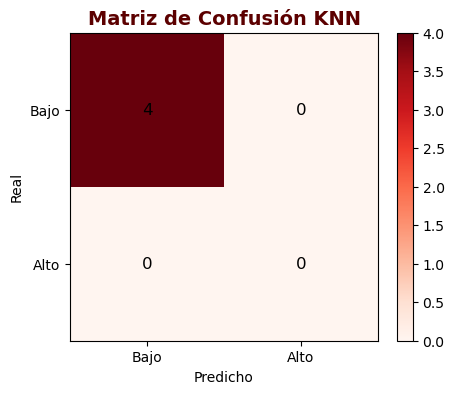

In [30]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt


cm_knn = confusion_matrix(
    y_test,
    y_pred_knn,
    labels=[0,1]
)


plt.figure(figsize=(5,4))


plt.imshow(
    cm_knn,
    cmap="Reds"
)


plt.title(
    "Matriz de Confusión KNN",
    fontsize=14,
    color="#5C0000",
    fontweight="bold"
)


plt.colorbar()


plt.xticks(
    [0,1],
    ["Bajo", "Alto"]
)

plt.yticks(
    [0,1],
    ["Bajo", "Alto"]
)


for i in range(2):
    for j in range(2):

        plt.text(
            j,
            i,
            cm_knn[i, j],
            ha="center",
            va="center",
            color="black",
            fontsize=12
        )


plt.xlabel("Predicho")
plt.ylabel("Real")


plt.show()

### Modelo Árbol de Decisión

### Configuración:

### criterion = gini
### max_depth = 3

In [31]:
tree = DecisionTreeClassifier(
    criterion="gini",
    max_depth=3,
    random_state=42
)

tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)

y_pred_tree

array([0, 0, 0, 0])

In [ ]:
Evaluación del Árbol de Decisión

In [ ]:
print("Accuracy Árbol:")

print(
    accuracy_score(
        y_test,
        y_pred_tree
    )
)

In [ ]:
print(
    classification_report(
        y_test,
        y_pred_tree,
        target_names=["Bajo", "Alto"]
    )
)

In [ ]:
Matriz de confusión Árbol de Decisión

In [ ]:
cm_tree = confusion_matrix(
    y_test,
    y_pred_tree
)

In [ ]:
Resultados obtenidos
KNN

Ventajas:

Considera similitudes entre registros
Buen desempeño con pocos datos

Desventajas:

Depende del escalado
Sensible al ruido

In [ ]:
Árbol de Decisión

Ventajas:

Fácil interpretación
No necesita escalado

Desventajas:

Puede sobreajustarse
Sensible a cambios pequeños

In [ ]:
Conclusiones

Ambos modelos permitieron clasificar correctamente el nivel de consumo de psicofármacos.

El modelo KNN mostró buen desempeño gracias al análisis de similitudes entre registros.

Por otro lado, el Árbol de Decisión permitió interpretar mejor cómo influyen las variables relacionadas con el consumo.

Debido a que el dataset es pequeño, los resultados pueden variar fácilmente y existe riesgo de sobreajuste.

Como mejoras futuras podrían aplicarse:

Más registros
Validación cruzada
Ajuste de hiperparámetros
Técnicas de balanceo
Nuevas variables predictoras